___

# Machine Learning in Geosciences 
Department of Applied Geoinformatics and Carthography, Charles University

Lukas Brodsky lukas.brodsky@natur.cuni.cz

## Exercise: Building and Evaluating Ensemble Models

This notebook is dedicated to ensemble learning exercizes. 

**Objective**:
Understand and implement different ensemble learning techniques — Bagging, Boosting, and Stacking and compare their performance.

Tasks: 
1. Implement Bagging using `BaggingClassifier()` and compare the result with a weak classifier, e.g. `DecisionTreeClassifier()` using high variance (noisy moons) dataset. 

2. Implement Boosting using `GradientBoostingClassifier()` and compare result with a weak classifier `DecisionTreeClassifier()` on  a complex decision boundary (circles) dataset. 

3. Implement Stacking using `StackingClassifier()` based on `SVC()`, `DecisionTreeClassifier()` and `KNeighborsClassifier()` and `LogisticRegression()`. Compare the stacking result with single weak classifiers, e.g. `DecisionTreeClassifier()`.  

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons, make_circles, make_classification
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.model_selection import cross_val_score
from sklearn.preprocessing import StandardScaler

# ensmbles 
from sklearn.ensemble import BaggingClassifier, GradientBoostingClassifier, StackingClassifier
# base estimators 
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

from sklearn.metrics import accuracy_score, classification_report

### Dataset 1 - bagging

In [97]:
# Dataset 1 for BAGGING: High Variance (Noisy Moons)
X_bagging, y_bagging = make_moons(n_samples=1000, noise=0.4, random_state=42)
X_train_bag, X_test_bag, y_train_bag, y_test_bag = train_test_split(X_bagging, y_bagging, 
                                                                    test_size=0.2, random_state=42)

Text(0.5, 1.0, 'Dataset: High Variance')

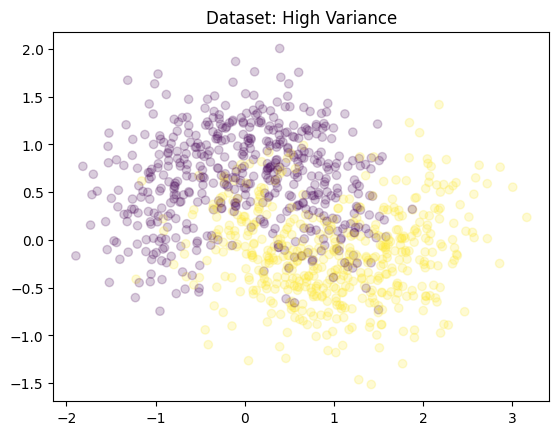

In [98]:
plt.scatter(X_bagging[:, 0], X_bagging[:, 1], c=y_bagging, cmap="viridis", alpha=0.2)
plt.title("Dataset: High Variance")

### Bagging classifier

**A Bagging classifier** is an ensemble meta-estimator that fits base classifiers each on random subsets of the original dataset and then aggregate their individual predictions (either by voting or by averaging) to form a final prediction. Such a meta-estimator can typically be used as a way to reduce the variance of a black-box estimator (e.g., a decision tree), by introducing randomization into its construction procedure and then making an ensemble out of it.

`
class sklearn.ensemble.BaggingClassifier(
    estimator=None, 
    n_estimators=10, 
    max_samples=1.0,
    max_features=1.0, 
    bootstrap=True,
    n_jobs=None
    )
`

In [99]:
# hyperparameters tunes number of estimators, sample size, and bootstrap settings.
bagging_params = {
    "n_estimators": [50, 100, 150, 200],
    "max_samples": [0.5, 0.8, 1.0]
}

In [100]:
bagging_params

{'n_estimators': [50, 100, 150, 200], 'max_samples': [0.5, 0.8, 1.0]}

In [101]:
# use GridSearchCV() on BaggingClassifier() with DecisionTreeClassifier()
# cv=10, return_train_score=True 
# bagging_grid = pass 

# Base weak lerner
dt = DecisionTreeClassifier(random_state=42)
# Ensemble learner 
bg = BaggingClassifier(estimator=dt) 
# Grid Search 
clf = GridSearchCV(bg, bagging_params, cv=3)

In [102]:
clf

GridSearchCV(cv=3,
             estimator=BaggingClassifier(estimator=DecisionTreeClassifier(random_state=42)),
             param_grid={'max_samples': [0.5, 0.8, 1.0],
                         'n_estimators': [50, 100, 150, 200]})

In [103]:
# search and fit 
clf.fit(X_train_bag, y_train_bag)

GridSearchCV(cv=3,
             estimator=BaggingClassifier(estimator=DecisionTreeClassifier(random_state=42)),
             param_grid={'max_samples': [0.5, 0.8, 1.0],
                         'n_estimators': [50, 100, 150, 200]})

In [104]:
# best paramters are: estimator.best_params_
clf.best_params_

{'max_samples': 0.5, 'n_estimators': 200}

In [105]:
# the best one is: estimator.best_estimator_
best_bc = clf.best_estimator_
best_bc

BaggingClassifier(estimator=DecisionTreeClassifier(random_state=42),
                  max_samples=0.5, n_estimators=200)

#### Model evaluation

In [106]:
# training score: estimator.best_score_
BC_train_acc = clf.best_score_
# BC_train_acc

In [107]:
# prediction for testing 
bagging_pred = best_bc.predict(X_test_bag) 
# bagging_pred

In [108]:
# accuracy: accuracy_score(y_test_bag, bagging_pred)
BC_test_acc = accuracy_score(y_test_bag, bagging_pred) 
BC_test_acc

0.845

In [109]:
# print the accuracies
print(f'Training acc. = {round(BC_train_acc, 4) * 100.}')
print(f'Testing acc. = {round(BC_test_acc, 4) * 100.}')

Training acc. = 84.61999999999999
Testing acc. = 84.5


#### Plot decision boundary

In [110]:
# Ensemble Decision Boundary
def plot_ensmble_boundary(model, X, y, title):
    h = 0.02
    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))

    for model in model.estimators_:
        Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
        Z = Z.reshape(xx.shape)
        cs = plt.contourf(xx, yy, Z, alpha=0.1)

    plt.scatter(X[:, 0], X[:, 1], c=y, edgecolors="k", marker="o", alpha=0.3)
    plt.title(title)

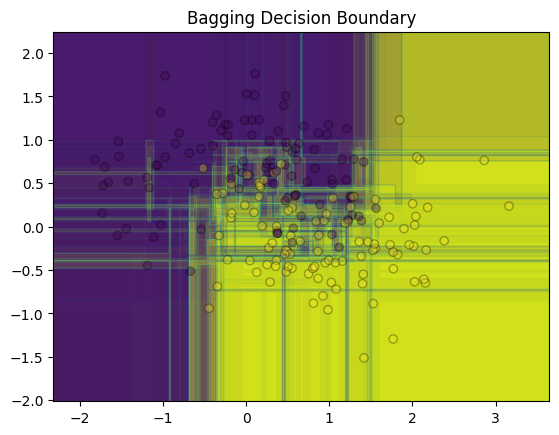

In [111]:
plot_ensmble_boundary(best_bc, X_test_bag, y_test_bag, "Bagging Decision Boundary")

### Single model Decision Tree

In [112]:
# DT DecisionTreeClassifier()  
dt = DecisionTreeClassifier(random_state=42)  

In [113]:
# fit the model 
dt.fit(X_train_bag, y_train_bag)

DecisionTreeClassifier(random_state=42)

In [114]:
train_pred = dt.predict(X_train_bag)
# train_pred

In [115]:
# training accuracy: accuracy_score()
DT_train_acc = accuracy_score(y_train_bag, train_pred) 

In [116]:
test_pred = dt.predict(X_test_bag)

In [117]:
# testing accuracy: accuracy_score()
DT_test_acc = accuracy_score(y_test_bag, test_pred) 
DT_test_acc

0.78

In [118]:
print(f'DT train acc. = {round(DT_train_acc, 4) * 100} %')
print(f'DT test acc. = {round(DT_test_acc, 4) * 100} %')

DT train acc. = 100.0 %
DT test acc. = 78.0 %


In [119]:
# Decision Boundary Plot
def plot_decision_boundary(model, X, y, title):
    h = 0.02
    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))

    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    plt.scatter(X[:, 0], X[:, 1], c=y, edgecolors="k", marker="o", alpha=0.3)
    plt.contourf(xx, yy, Z, alpha=0.5)

    plt.title(title)

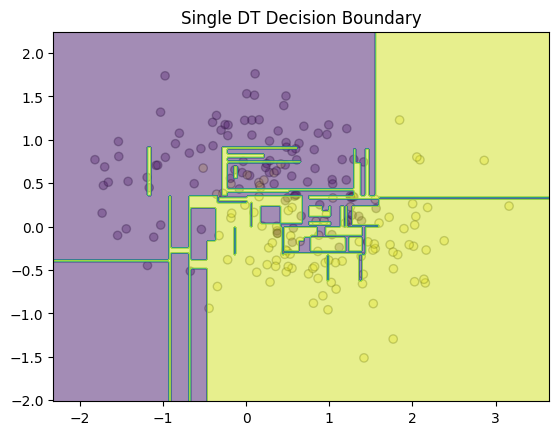

In [120]:
plot_decision_boundary(dt, X_test_bag, y_test_bag, "Single DT Decision Boundary")

#### Models comparison (accuarcy)

In [121]:
print("\n===== Models Comparision =====")
print(f'Bagging training error: {round(BC_train_acc, 2)}')
print(f'Bagging testing  error: {round(BC_test_acc , 2)}')
print('---')
print(f'Decition Tree training: {round(DT_train_acc, 2)}')
print(f'Decition Tree training: {round(DT_test_acc, 2)}')


===== Models Comparision =====
Bagging training error: 0.85
Bagging testing  error: 0.84
---
Decition Tree training: 1.0
Decition Tree training: 0.78


### Does averaging weak learners reduces overfitting on noisy data? 

.

### Boosting classifier 

**Gradient Boosting** for classification builds an additive model in a forward stage-wise fashion; it allows for the optimization of arbitrary differentiable loss functions. In each stage n_classes_ regression trees are fit on the negative gradient of the loss function, e.g. binary or multiclass log loss. 

`
class sklearn.ensemble.GradientBoostingClassifier(
    n_estimators=100, 
    learning_rate=0.1, 
    max_depth=3
    )
`

where learning rate shrinks the contribution of each tree by learning_rate. There is a trade-off between learning_rate and n_estimators. Values must be in the range [0.0, inf).

### Dataset 2 - boosting 

In [122]:
# Dataset 2 for BOOSTING: Complex Decision Boundary (Circles)
X_boosting, y_boosting = make_circles(n_samples=1000, noise=0.2, factor=0.5, random_state=42)
X_train_boost, X_test_boost, y_train_boost, y_test_boost = train_test_split(X_boosting, y_boosting, test_size=0.2, random_state=42)

Text(0.5, 1.0, 'Dataset: Complex Decision Boundary')

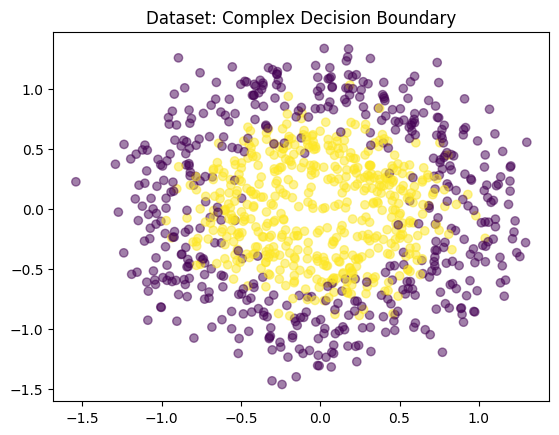

In [123]:
plt.scatter(X_boosting[:, 0], X_boosting[:, 1], c=y_boosting, cmap="viridis", alpha=0.5)
plt.title("Dataset: Complex Decision Boundary")

### Boosting classifier

In [158]:
# Boosting model
boosting_clf = GradientBoostingClassifier(n_estimators=50, learning_rate=0.1, random_state=42)

In [201]:
# Boosting: optimizes tree depth, learning rate, and number of estimators
boosting_params = {
    "n_estimators": [50, 200, 500],
    "learning_rate": [0.005, 0.01],
    "max_depth": [2, 3]
}

In [202]:
# run GridSearchCV() on GradientBoostingClassifier 
# cv=5
boosting_grid = GridSearchCV(boosting_clf, boosting_params, cv=3) 

In [203]:
# fit through grid search CV 
boosting_grid.fit(X_train_boost, y_train_boost) 

GridSearchCV(cv=3,
             estimator=GradientBoostingClassifier(n_estimators=50,
                                                  random_state=42),
             param_grid={'learning_rate': [0.005, 0.01], 'max_depth': [2, 3],
                         'n_estimators': [50, 200, 500]})

In [204]:
# the best one: boosting_estimator.best_estimator_
boosting_grid.best_estimator_

GradientBoostingClassifier(learning_rate=0.01, n_estimators=200,
                           random_state=42)

In [205]:
# training score: boosting_estimator.best_score_
Boost_train_acc = boosting_grid.best_score_
Boost_train_acc

0.8837543296443355

In [206]:
best_boost = boosting_grid.best_estimator_
# best_boost

In [207]:
# test the model 
boosting_pred = best_boost.predict(X_test_boost) 
# boosting_pred

In [208]:
# testing acccuracy accuracy_score()
Boost_test_acc = accuracy_score(y_test_boost, boosting_pred) 
Boost_test_acc

0.825

In [209]:
# print
print(f'Boosting train acc. {round(Boost_train_acc, 2)*100} %')
print(f'Boosting test acc. {round(Boost_test_acc, 2)*100} %')

Boosting train acc. 88.0 %
Boosting test acc. 82.0 %


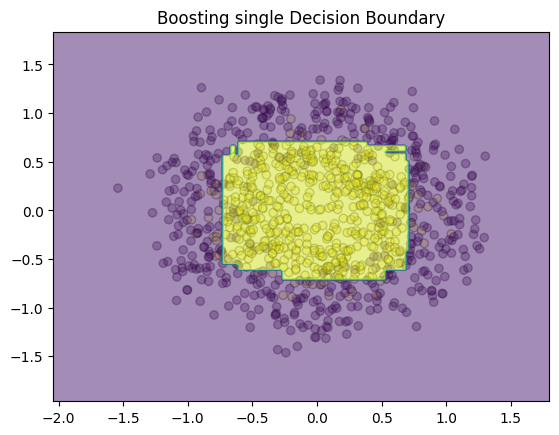

In [210]:
plot_decision_boundary(best_boost, X_boosting, y_boosting, "Boosting single Decision Boundary")

In [211]:
# Function to Plot Decision Boundaries at Different Stages
def plot_decision_boundaries_ensemble(model, X, y, stages=[1, 5, 50, 100], 
                                      title="Gradient Boosting Evolution"):
    h = 0.02  # Step size in meshgrid
    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))

    fig, axes = plt.subplots(1, len(stages), figsize=(15, 4))
    for ax, stage in zip(axes, stages):
        # Partial predictions using first `stage` trees
        stage_model = GradientBoostingClassifier(n_estimators=stage, learning_rate=0.1, random_state=42)
        stage_model.fit(X, y)
        Z = stage_model.predict(np.c_[xx.ravel(), yy.ravel()])
        Z = Z.reshape(xx.shape)

        # Plot decision boundary
        ax.contourf(xx, yy, Z, alpha=0.5)
        ax.set_title(f"{stage} Model(s)")
        ax.scatter(X[:, 0], X[:, 1], c=y, edgecolors="k", marker="o", alpha=0.1)
    plt.suptitle(title)
    plt.show()

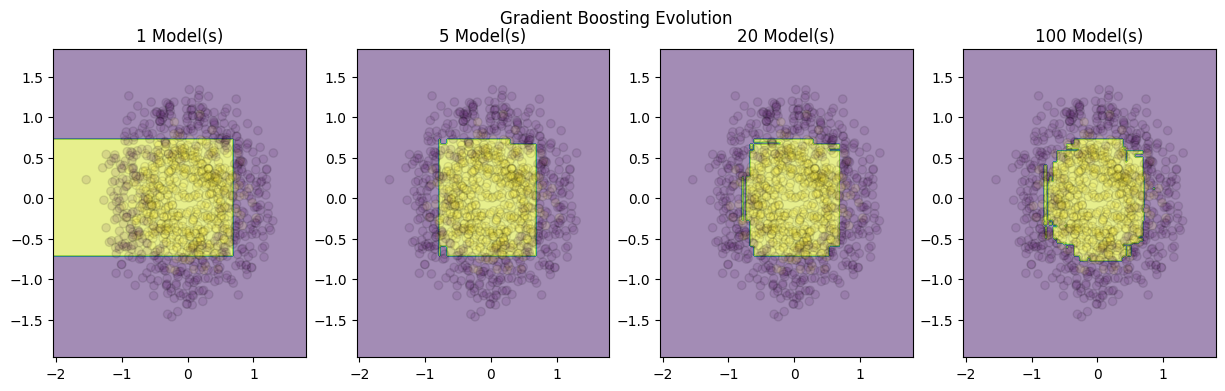

In [212]:
plot_decision_boundaries_ensemble(best_boost, X_boosting, y_boosting, stages=[1, 5, 20, 100], 
                                  title="Gradient Boosting Evolution")

### Weaker classifier

In [213]:
# DecisionTreeClassifier()
dt = DecisionTreeClassifier(random_state=42)

In [214]:
# fit model
dt.fit(X_train_boost, y_train_boost)

DecisionTreeClassifier(random_state=42)

In [219]:
# training accuracy
pred_acc = dt.predict(X_train_boost)
DT_train_acc = accuracy_score(y_train_boost, pred_acc)
DT_train_acc * 100

100.0

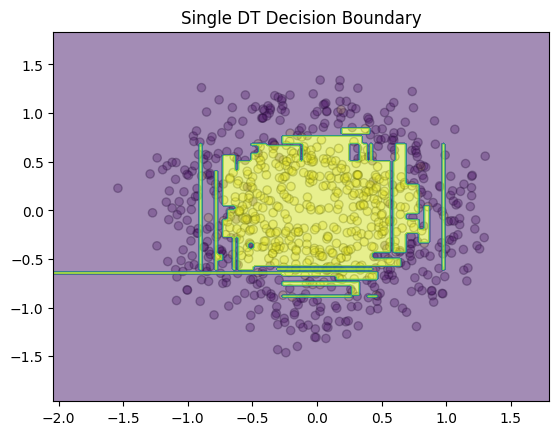

In [220]:
plot_decision_boundary(dt, X_train_boost, y_train_boost, "Single DT Decision Boundary")

In [ ]:
print("\n===== Models Comparision =====")
print(f'Boosting training error: {round(Boost_train_acc, 2)}')
print(f'Boosting testing  error: {round(Boost_test_acc, 2)}')
print('---')
print(f'Decition Tree training: {round(DT_train_acc, 2)}')
print(f'Decition Tree training: {round(DT_test_acc, 2)}')

### Does boosting improves weak model errors in overlapping, complex patterns? 

.

### Stacking 

**Stack of estimators with a final classifier** consists in stacking the output of individual estimator and use a classifier to compute the final prediction. Stacking allows to use the strength of each individual estimator by using their output as input of a final estimator.

`
class sklearn.ensemble.StackingClassifier(
    estimators,
    final_estimator
    )
`

wehere `estimators` are base estimators, 
and `final_estimator` is a classifier which will be used to combine the base estimators. The default classifier is a LogisticRegression.

### Dataset 3 - stacking

In [221]:
# Dataset 3 for STACKING: Diverse Model Mistakes (Classification)
X_stacking, y_stacking = make_classification(n_samples=1000, n_features=10, n_informative=3, class_sep=0.5, 
                                             n_redundant=2, n_clusters_per_class=2, random_state=42)

X_train_stack, X_test_stack, y_train_stack, y_test_stack = train_test_split(X_stacking, y_stacking, 
                                                                            test_size=0.2, random_state=42)

In [222]:
X_train_stack.shape

(800, 10)

In [223]:
# use SVM, DT, and KNN 
stacking_estimators = [
    ('svm', SVC(probability=True, kernel='rbf', random_state=42)),
    ('dt', DecisionTreeClassifier(random_state=42)),
    ('knn', KNeighborsClassifier(n_neighbors=5))
]

In [281]:
stacking_estimators = [
    ('dt', DecisionTreeClassifier(random_state=42)),
    ('knn', KNeighborsClassifier(n_neighbors=5))
]

In [282]:
stacking_estimators[0]

('dt', DecisionTreeClassifier(random_state=42))

In [283]:
# stacking: fine-tunes Logistic Regression used as the meta-classifier. 
stacking_params = {
    "final_estimator__C": [0.1, 1, 10]  # regularization strength 
}

In [284]:
sc = StackingClassifier(estimators=stacking_estimators, final_estimator=LogisticRegression()) 

In [285]:
sc

StackingClassifier(estimators=[('dt', DecisionTreeClassifier(random_state=42)),
                               ('knn', KNeighborsClassifier())],
                   final_estimator=LogisticRegression())

In [286]:
# run GridSearchCV() on StackingClassifier() using e.g. cv=10 
stacking_grid = GridSearchCV(sc, stacking_params, cv=3)  
# stacking_grid

In [287]:
# search and fit 
stacking_grid.fit(X_train_stack, y_train_stack)

GridSearchCV(cv=3,
             estimator=StackingClassifier(estimators=[('dt',
                                                       DecisionTreeClassifier(random_state=42)),
                                                      ('knn',
                                                       KNeighborsClassifier())],
                                          final_estimator=LogisticRegression()),
             param_grid={'final_estimator__C': [0.1, 1, 10]})

In [288]:
# the best one is: .best_estimator_
stacking_best = stacking_grid.best_estimator_
stacking_best

StackingClassifier(estimators=[('dt', DecisionTreeClassifier(random_state=42)),
                               ('knn', KNeighborsClassifier())],
                   final_estimator=LogisticRegression(C=0.1))

In [289]:
spass = stacking_best
spass

StackingClassifier(estimators=[('dt', DecisionTreeClassifier(random_state=42)),
                               ('knn', KNeighborsClassifier())],
                   final_estimator=LogisticRegression(C=0.1))

In [290]:
# training score: .best_score_
Stack_train_acc = stacking_grid.best_score_ 
Stack_train_acc * 100

79.38150619995682

In [291]:
# testing: 
stacking_pred = spass.predict(X_test_stack)

In [292]:
# testing accuracy
Stack_test_acc = accuracy_score(y_test_stack, stacking_pred) 
Stack_test_acc

0.78

In [293]:
# print
print(f'Stack train acc. {Stack_train_acc * 100}')
print(f'Stack test acc. {Stack_test_acc * 100}')

Stack train acc. 79.38150619995682
Stack test acc. 78.0


### Weaker classifiers

In [294]:
('svm', SVC(probability=True, kernel='rbf', random_state=42)),
    ('dt', DecisionTreeClassifier(random_state=42)),
    ('knn', KNeighborsClassifier(n_neighbors=5))

IndentationError: unexpected indent (4155101398.py, line 2)

In [295]:
# SVM: SVC(probability=True, kernel='rbf', random_state=42) 
svm = SVC(probability=True, kernel='rbf', random_state=42)

In [296]:
# fit 
svm.fit(X_train_stack, y_train_stack)

SVC(probability=True, random_state=42)

In [297]:
# training accuracy
SVM_train_acc = accuracy_score(y_train_stack, svm.predict(X_train_stack))
SVM_train_acc

0.85875

In [298]:
# testing accuracy 
SVM_test_acc = accuracy_score(y_test_stack, svm.predict(X_test_stack))
SVM_test_acc

0.795

In [299]:
# DT: DecisionTreeClassifier()  
dt = DecisionTreeClassifier(random_state=42)

In [300]:
# fit
dt.fit(X_train_stack, y_train_stack)

DecisionTreeClassifier(random_state=42)

In [301]:
# training accuracy 
DT_train_acc = accuracy_score(y_train_stack, dt.predict(X_train_stack))
DT_train_acc

1.0

In [302]:
# testing accuracy 
DT_test_acc = accuracy_score(y_test_stack, dt.predict(X_test_stack))
DT_test_acc

0.76

In [303]:
# KNN: KNeighborsClassifier(n_neighbors=10)
knn = KNeighborsClassifier(n_neighbors=20)

In [304]:
# fit 
knn.fit(X_train_stack, y_train_stack)

KNeighborsClassifier(n_neighbors=20)

In [305]:
# training accuracy 
KNN_train_acc = accuracy_score(y_train_stack, knn.predict(X_train_stack))
KNN_train_acc

0.82875

In [306]:
# testing accuracy 
KNN_test_acc = accuracy_score(y_test_stack, knn.predict(X_test_stack))
KNN_test_acc 

0.77

In [272]:
print("\n===== Models Comparision =====")
print(f'Stacking training error: {round(Stack_train_acc, 2)}')
print(f'Stacking testing  error: {round(Stack_test_acc, 2)}')
print('===')
print(f'SVM model training: {round(SVM_train_acc, 2)}')
print(f'SVM model testing: {round(SVM_test_acc, 2)}')
print('---')
print(f'Decition Tree training: {round(DT_train_acc, 2)}')
print(f'Decition Tree testing: {round(DT_test_acc, 2)}')
print('---')
print(f'KNN model training: {round(KNN_train_acc, 2)}')
print(f'KNN model testing: {round(KNN_test_acc, 2)}')


===== Models Comparision =====
Stacking training error: 0.81
Stacking testing  error: 0.81
===
SVM model training: 0.86
SVM model testing: 0.8
---
Decition Tree training: 1.0
Decition Tree testing: 0.76
---
KNN model training: 0.83
KNN model testing: 0.77


In [307]:
print("\n===== Models Comparision =====")
print(f'Stacking training error: {round(Stack_train_acc, 2)}')
print(f'Stacking testing  error: {round(Stack_test_acc, 2)}')
print('===')
print(f'SVM model training: {round(SVM_train_acc, 2)}')
print(f'SVM model testing: {round(SVM_test_acc, 2)}')
print('---')
print(f'Decition Tree training: {round(DT_train_acc, 2)}')
print(f'Decition Tree testing: {round(DT_test_acc, 2)}')
print('---')
print(f'KNN model training: {round(KNN_train_acc, 2)}')
print(f'KNN model testing: {round(KNN_test_acc, 2)}')


===== Models Comparision =====
Stacking training error: 0.79
Stacking testing  error: 0.78
===
SVM model training: 0.86
SVM model testing: 0.8
---
Decition Tree training: 1.0
Decition Tree testing: 0.76
---
KNN model training: 0.83
KNN model testing: 0.77


### Does boosting improves weak model errors in overlapping, complex patterns? 

.

### Final thoughts

**1. Bagging (Random Forest)** 
   
Questions: 

    Is the model robust on noisy data? 
    Is it true that the high-variance dataset benefits from model averaging? 
    Is it true that Bagging leads to less overfitting compared to a single decision tree.
    

**2. Boosting** 

Questions: 

    Is it true that it corrects mistakes iteratively, capturing non-linear interactions better? 
    Is it true that it would outperform traditional models like Decision Trees.
    

**3. Stacking** 

Questions: 

    Does it works better when different models make different errors? 
    Is it true that stacking leverages these complementary strengths for improved accuracy? 